In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10}) 

# Load the dataset
df = pd.read_csv("reports/CIA2_Full_Metrics_Report.csv")

C:\Users\addys\AppData\Local\Temp\ipykernel_51624\2719819378.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Variation'] == var], x='Embedding', y='Accuracy', palette='Set2')
C:\Users\addys\AppData\Local\Temp\ipykernel_51624\2719819378.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Variation'] == var], x='Embedding', y='Accuracy', palette='Set2')
C:\Users\addys\AppData\Local\Temp\ipykernel_51624\2719819378.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Variation'] == var], x='Embedding', y

<Figure size 640x480 with 0 Axes>

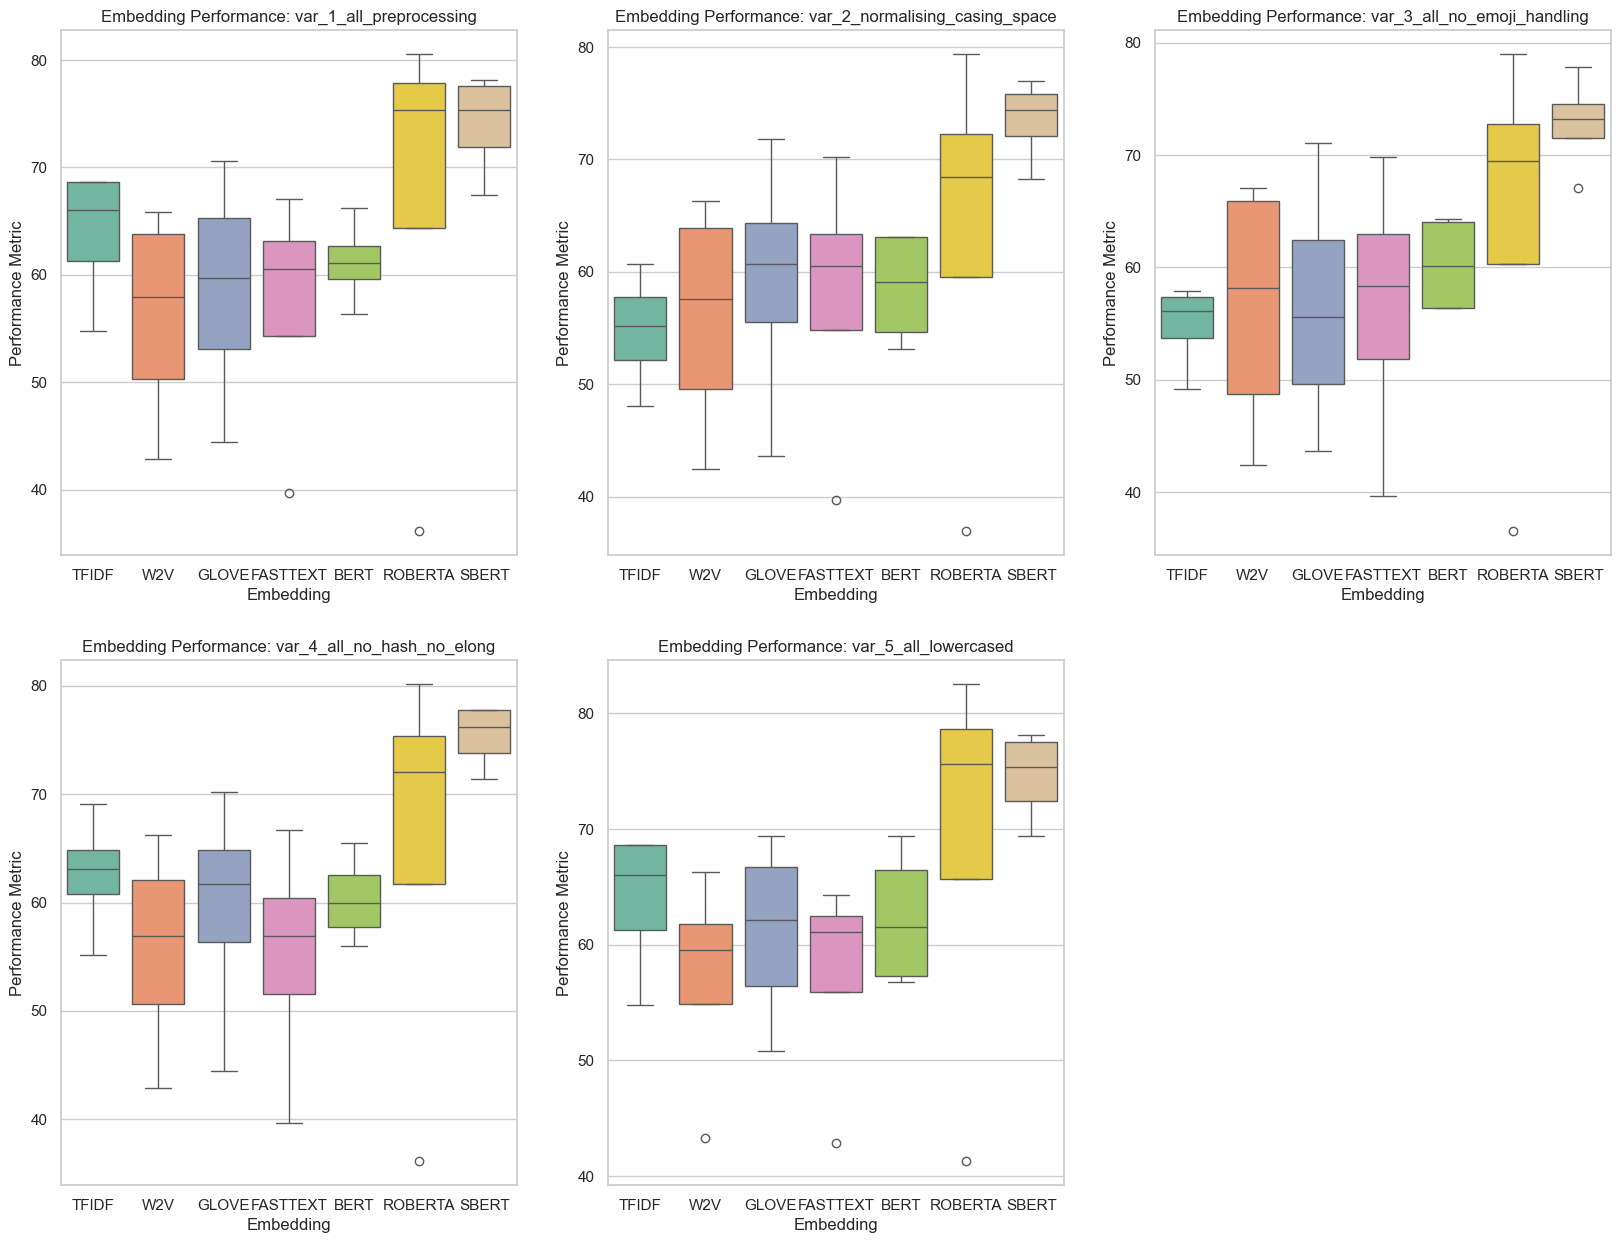

In [ ]:
# PLOT 1: The Embedding Showdown (Boxplot)
# Goal: Shows the absolute power and stability of Contextual vs Static embeddings across different variants.

variations = ['var_1_all_preprocessing', 'var_2_normalising_casing_space', 'var_3_all_no_emoji', 'var_4_all_no_hash_no_elong','var_5_all_lowercased']
plt.subplots_adjust(hspace=0.4) 
# bigger size for better visibility
plt.figure(figsize=(20, 15))
for var in variations:    
    plt.subplot(2, 3, variations.index(var) + 1)
    sns.boxplot(data=df[df['Variation'] == var], x='Embedding', y='Accuracy', palette='Set2')
    plt.title(f'Embedding Performance: {var}')
    if var == 'var_3_all_no_emoji':
        plt.title('Embedding Performance: var_3_all_no_emoji_handling')
    plt.ylabel('Performance Metric')

C:\Users\addys\AppData\Local\Temp\ipykernel_51624\3251761269.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Classifier', y='Accuracy', palette='viridis', capsize=0.1)


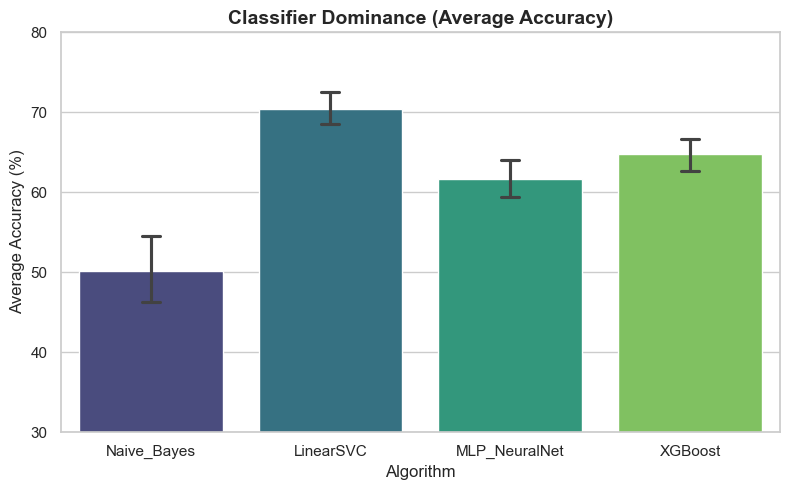

In [ ]:
# PLOT 2: The Classifier Showdown (Barplot)
# Goal: Shows which mathematical approach handled the high-dimensional vectors best.
plt.figure(figsize=(8, 5))
# We use a barplot to show the mean accuracy with error bars for variance
sns.barplot(data=df, x='Classifier', y='Accuracy', palette='viridis', capsize=0.1)
plt.title('Classifier Dominance (Average Accuracy)', fontsize=14, fontweight='bold')
plt.ylabel('Average Accuracy (%)')
plt.xlabel('Algorithm')
plt.ylim(30, 80)
plt.tight_layout()
plt.show()


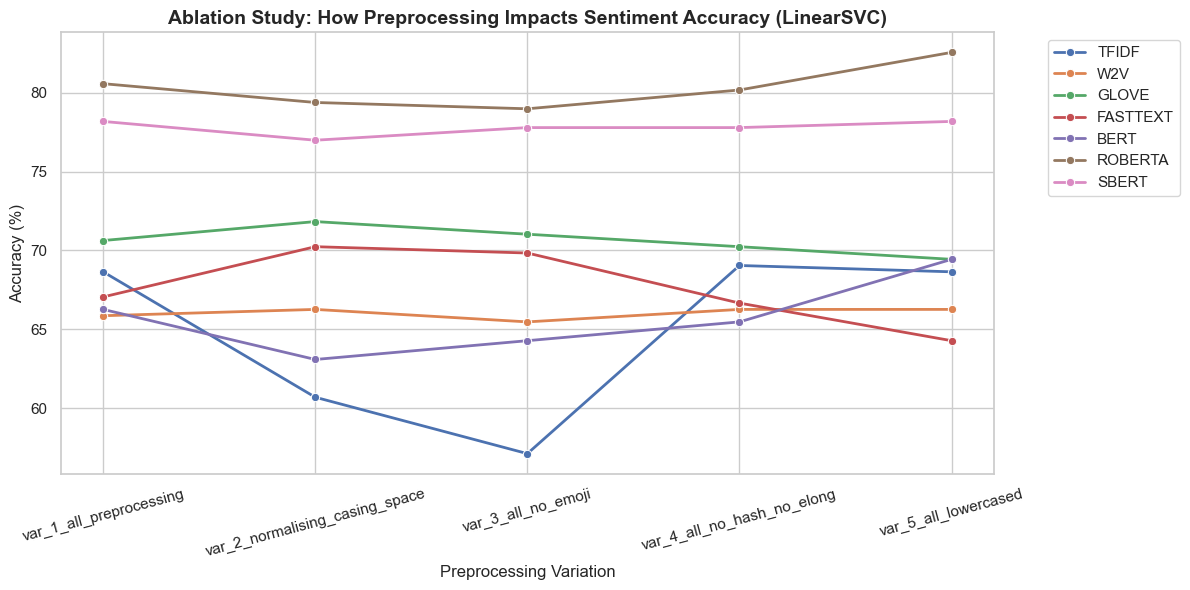

In [ ]:
# PLOT 3: The Ablation Study Impact (Lineplot)
# Goal: Proves exactly which preprocessing variation helped the models the most.
plt.figure(figsize=(12, 6))
best_clf_data = df[df['Classifier'] == 'LinearSVC']  
sns.lineplot(data=best_clf_data, x='Variation', y='Accuracy', hue='Embedding', marker='o', linewidth=2)
plt.title('Ablation Study: How Preprocessing Impacts Sentiment Accuracy (LinearSVC)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xlabel('Preprocessing Variation')
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


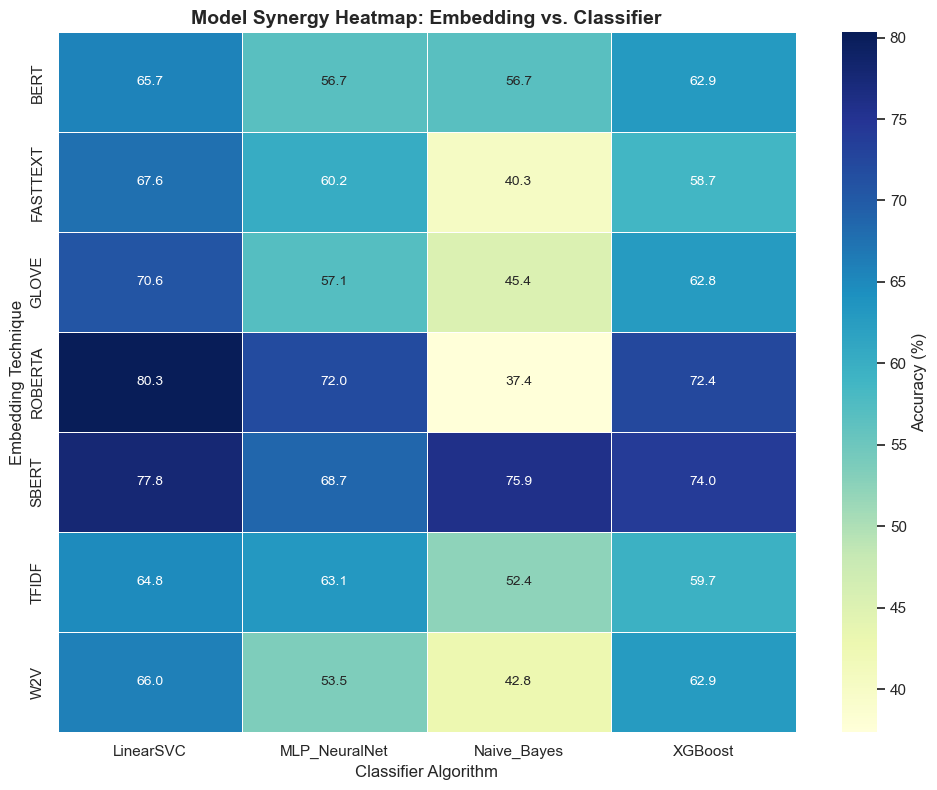

In [ ]:
# PLOT 4: The Synergy Heatmap (Best Combinations)
# Goal: A beautiful matrix showing exactly which Embedder + Classifier pairs dominate.
plt.figure(figsize=(10, 8))
heatmap_data = df.pivot_table(index='Embedding', columns='Classifier', values='Accuracy', aggfunc='mean')

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Accuracy (%)'})
plt.title('Model Synergy Heatmap: Embedding vs. Classifier', fontsize=14, fontweight='bold')
plt.ylabel('Embedding Technique')
plt.xlabel('Classifier Algorithm')
plt.tight_layout()
plt.show()

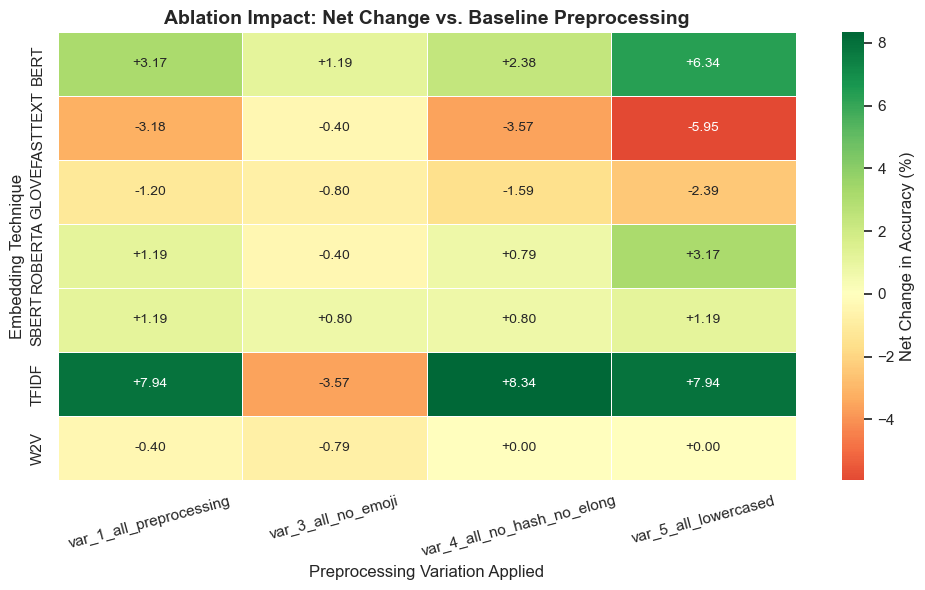

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("reports/CIA2_Full_Metrics_Report.csv")

# Filter to your best classifier to keep it clean (e.g., LinearSVC)
best_clf_df = df[df['Classifier'] == 'LinearSVC'].copy()

# Pivot the data so Variations are Columns and Embeddings are Rows
pivot_df = best_clf_df.pivot(index='Embedding', columns='Variation', values='Accuracy')

# Calculate the DELTA (Difference from Baseline)
baseline_col = 'var_2_normalising_casing_space'

# Subtract the baseline from all columns to get the net change
delta_df = pivot_df.subtract(pivot_df[baseline_col], axis=0)

# Drop the baseline column itself (since it will just be a column of zeros)
delta_df = delta_df.drop(columns=[baseline_col])

# Plotting the Delta Heatmap
plt.figure(figsize=(10, 6))
# Use a diverging colormap: Red for negative impact, Green for positive impact
sns.heatmap(delta_df, annot=True, fmt="+0.2f", cmap="RdYlGn", center=0, 
            linewidths=.5, cbar_kws={'label': 'Net Change in Accuracy (%)'})

plt.title('Ablation Impact: Net Change vs. Baseline Preprocessing', fontsize=14, fontweight='bold')
plt.ylabel('Embedding Technique')
plt.xlabel('Preprocessing Variation Applied')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
df = pd.read_csv("reports/CIA2_Misclassified_Comments_Log.csv")

 # Filter for Word2Vec embedding

In [3]:
filter_df = df[(df['Embedding'] == 'TFIDF') & (df['Variation'] == 'var_1_all_preprocessing')] 

In [4]:
filter_df['True_Label'].value_counts()  

True_Label
0    160
2    107
1     97
Name: count, dtype: int64